# Indicator vs Monthly Return Testing

This notebook loads a JSON file containing indicator values and a monthly return variable, then automatically generates scatter plots of each indicator vs the monthly return.

In [1]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_val_score


In [2]:
import os
print(os.getcwd())


c:\Users\micha\OneDrive\Desktop\TUE\HTT\Notebooks


In [4]:

path = Path.cwd().parent / "analysis_output" / "clean_dataset.csv"
jdf = pd.read_csv(path)
jdf

,Ticker,Date,BOED,OCF/BOED,ROA,CostExpenses/BOED,Stock/Oil ZScore,PGR,Monthly Return
0,NFG,2025-12-31,53051.0,5182.202032,1.973143,7075.908088,2.825966,11.730000,8.880840
1,COP,2025-12-31,224000.0,88375.000000,6.550816,29205.357143,1.994985,21.739130,16.205524
2,FANG,2025-12-31,497156.0,17616.200951,2.341716,27677.429217,2.364790,53.530000,12.146607
3,DVN,2025-12-31,389000.0,17251.928021,8.361024,7275.064267,1.153904,-0.410000,20.229319
4,EXE,2025-12-31,16164.0,283036.377134,6.430516,597191.289285,2.376671,90.672727,-6.895615
...,...,...,...,...,...,...,...,...,...
765,CKX,1998-12-31,100000.0,4.419620,8.743000,2.191770,-0.371745,0.000000,-4.316563
766,CKX,1998-09-30,21176000.0,0.020871,8.743000,0.010350,-0.371745,829.587357,-4.316563
767,MXC,1998-03-31,104401.0,11.141186,0.976244,29.401519,-0.713093,0.000000,1.960771
768,CKX,1998-03-31,17610000.0,0.025097,8.743000,0.012446,-0.371745,674.070000,-4.316563


In [35]:

path = Path.cwd().parent / "Data" / "oil_industry_data.json"
jdf = pd.read_json(path)
jdf

,XOM,CVX,SHEL,TTE,PBR,PBR.A,BP,EQNR,E,SU,...,CRT,PVL,PRT,USEG,MXC,CKX,EONR,BRN,MTR,TPET
2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
2025-09-30,NaN,"{'BOED': 6609000, 'OCF/BOED': 3502.79921319412...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 1000000, 'OCF/BOED': 0.336296, 'ROA':...",NaN,NaN,NaN,NaN
2025-06-30,NaN,"{'BOED': 3346500, 'OCF/BOED': 4113.25265202450...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 150000, 'OCF/BOED': 0.626840000000000...",NaN,NaN,NaN,NaN
2024-12-31,NaN,"{'BOED': 3338000, 'OCF/BOED': 9434.39185140802...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'BOED': 225.33, 'OCF/BOED': 13052.47858696134...","{'BOED': 22061.19, 'OCF/BOED': 9.2815029470305...",NaN,NaN,NaN,NaN
2025-03-31,NaN,"{'BOED': 13412000, 'OCF/BOED': 386.89233522218...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 100000, 'OCF/BOED': 1.186640000000000...",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1995-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN


In [38]:
s = jdf.stack()
s = s[s.map(type).eq(dict)]

out = pd.json_normalize(s.values)
out.index = s.index

out

out = out.reset_index()
out.columns = ['Date', 'Ticker'] + list(out.columns[2:])
out = out.drop(columns='Date')


out

,Ticker,BOED,OCF/BOED,ROA,CostExpenses/BOED,Stock/Oil ZScore,PGR,Monthly Return
0,NFG,53051.0,5182.202032,1.973143,7075.908088,2.825966,11.730000,8.880840
1,COP,224000.0,88375.000000,6.550816,29205.357143,1.994985,21.739130,16.205524
2,FANG,497156.0,17616.200951,2.341716,27677.429217,2.364790,53.530000,12.146607
3,DVN,389000.0,17251.928021,8.361024,7275.064267,1.153904,-0.410000,20.229319
4,EXE,16164.0,283036.377134,6.430516,597191.289285,2.376671,90.672727,-6.895615
...,...,...,...,...,...,...,...,...
765,CKX,100000.0,4.419620,8.743000,2.191770,-0.371745,0.000000,-4.316563
766,CKX,21176000.0,0.020871,8.743000,0.010350,-0.371745,829.587357,-4.316563
767,MXC,104401.0,11.141186,0.976244,29.401519,-0.713093,0.000000,1.960771
768,CKX,17610000.0,0.025097,8.743000,0.012446,-0.371745,674.070000,-4.316563


In [66]:
X =  out.drop(columns= ["Ticker", "Monthly Return"])
y =  out[["Monthly Return"]]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)


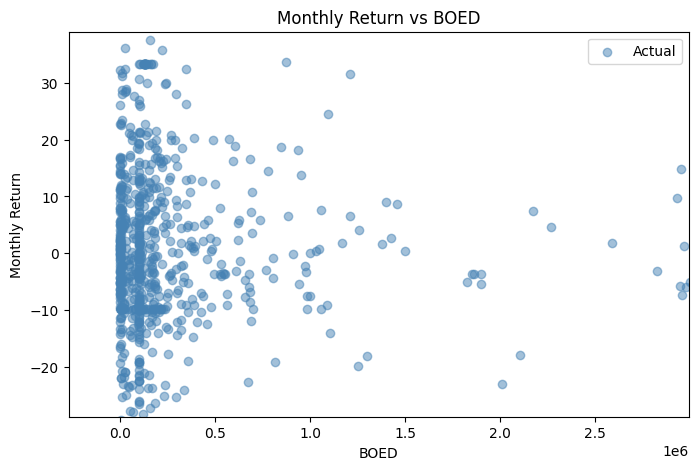

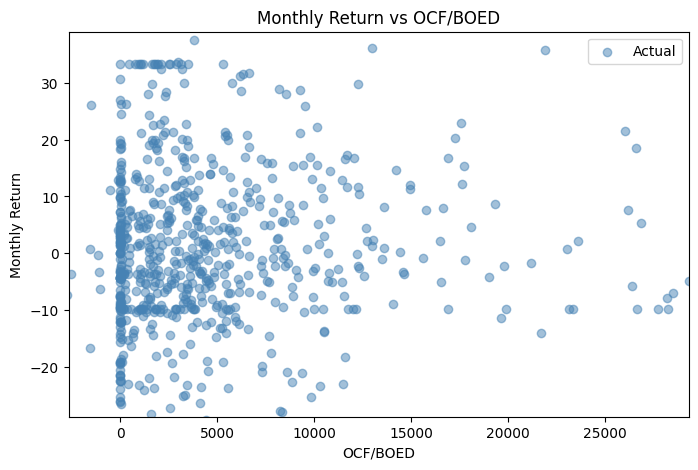

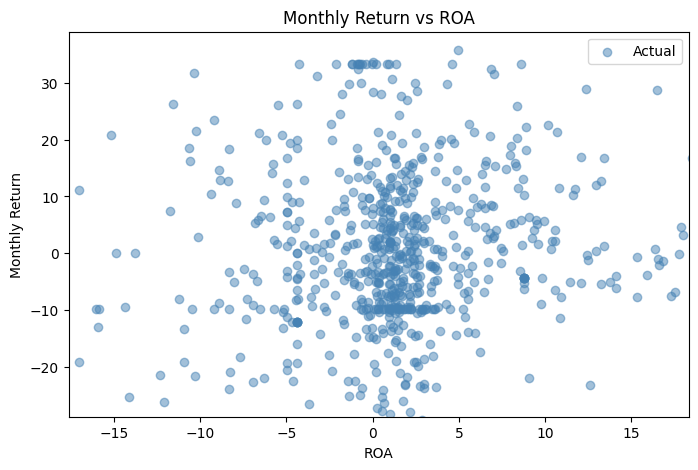

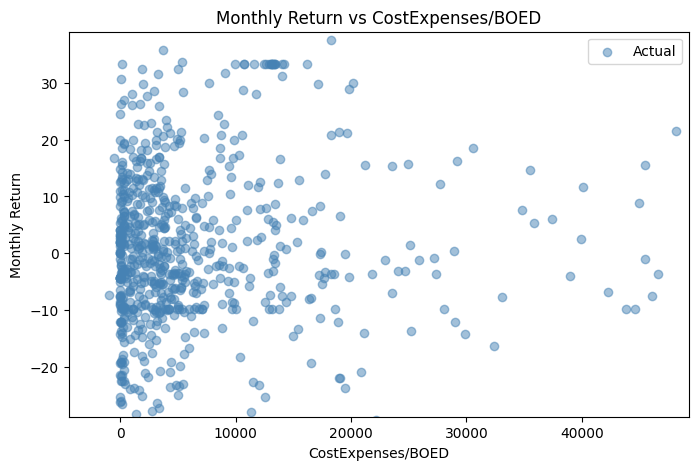

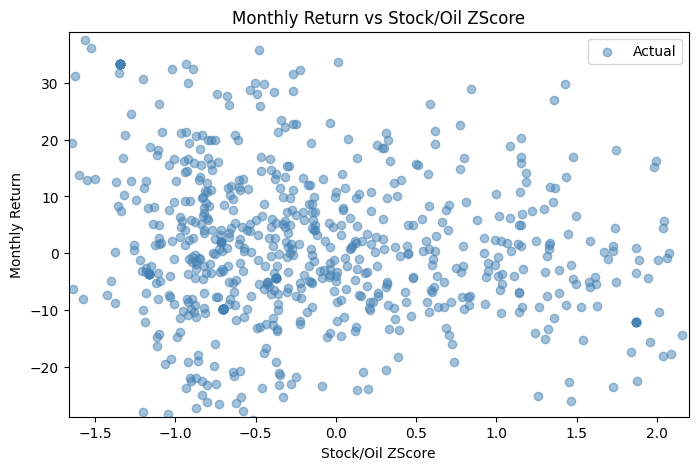

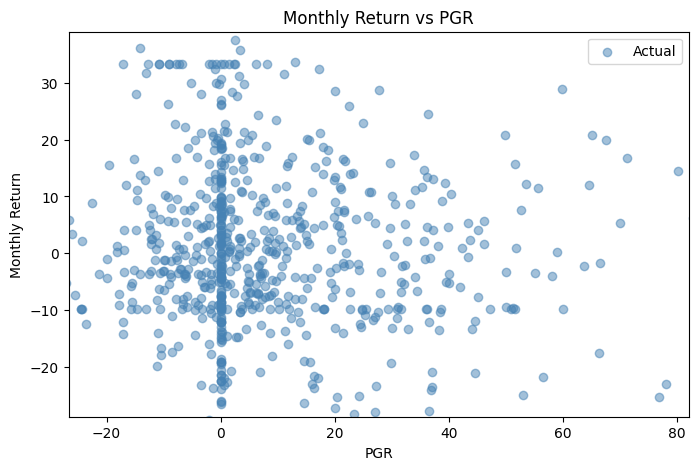

In [58]:
for col in X.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.scatter(X[col], y, alpha=0.5, color='steelblue', label='Actual')
    
    # Use percentiles to ignore outliers
    x_low, x_high = X[col].quantile(0.05), X[col].quantile(0.95)
    y_low, y_high = y.quantile(0.05).item(), y.quantile(0.95).item()
    
    x_pad = (x_high - x_low) * 0.1
    y_pad = (y_high - y_low) * 0.1
    
    ax.set_xlim(x_low - x_pad, x_high + x_pad)
    ax.set_ylim(y_low - y_pad, y_high + y_pad)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Monthly Return')
    ax.set_title(f'Monthly Return vs {col}')
    ax.legend()
    plt.show()

In [78]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
model.coef_

array([[-3.47199879e-08,  3.70790841e-05, -2.04894230e-02,
        -3.06141098e-05, -3.70499540e+00, -1.71442256e-03]])

In [82]:
model = RandomForestRegressor(n_estimators=200, random_state=0)
model.fit(X_train,y_train)

c:\Users\micha\OneDrive\Desktop\TUE\HTT\venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [84]:
preds = model.predict(X_test)

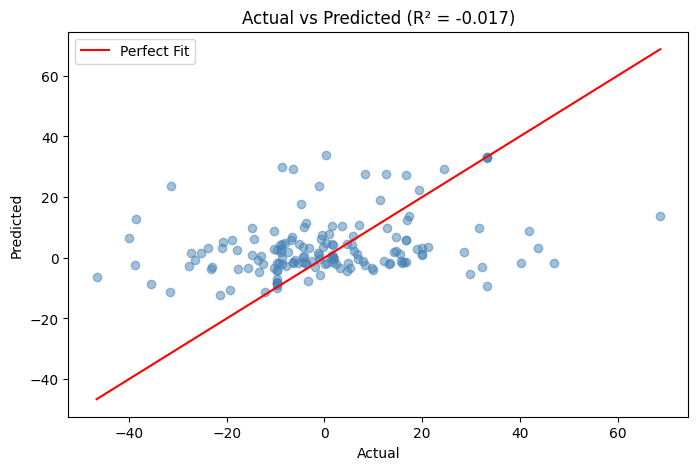

In [85]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Actual vs Predicted (R² = {r2_score(y_test, preds):.3f})')
plt.legend()
plt.show()